C:\Users\splas\AppData\Local\Temp\ipykernel_12076\3348734115.py:21: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ..\torch\csrc\utils\tensor_new.cpp:277.)
  return torch.tensor(data, dtype=torch.float32).unsqueeze(-1)  # [B, T, 1]


Epoch 10: Loss = 0.1535
Epoch 20: Loss = 0.1361
Epoch 30: Loss = 0.1179
Epoch 40: Loss = 0.1153
Epoch 50: Loss = 0.1157
Epoch 60: Loss = 0.1149
Epoch 70: Loss = 0.1142
Epoch 80: Loss = 0.1145
Epoch 90: Loss = 0.1143
Epoch 100: Loss = 0.1145


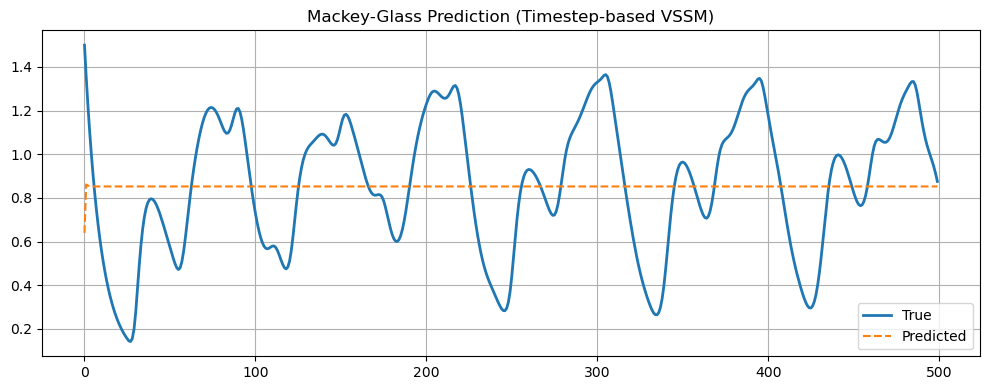

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# ===== 1. Generate Mackey-Glass Data =====
def generate_mackey_glass(x0, beta=0.2, gamma=0.1, n=10, tau=25, dt=1, T=500):
    delay = int(tau / dt)
    x = np.zeros(T + delay)
    x[:delay + 1] = x0
    for t in range(delay, T + delay - 1):
        x[t + 1] = x[t] + dt * (beta * x[t - delay] / (1 + x[t - delay]**n) - gamma * x[t])
    return x[delay:]

def generate_dataset(n_ics=10, T=500):
    data = []
    for x0 in np.linspace(1.5, 3.0, n_ics):
        series = generate_mackey_glass(x0, T=T)
        data.append(series)
    return torch.tensor(data, dtype=torch.float32).unsqueeze(-1)  # [B, T, 1]

# ===== 2. VSSM Components =====
class Encoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super().__init__()
        self.rnn = nn.GRU(input_dim, 64, batch_first=True)
        self.fc_mu = nn.Linear(64, latent_dim)
        self.fc_logvar = nn.Linear(64, latent_dim)

    def forward(self, x):
        _, h = self.rnn(x)   # h: [1, B, 64]
        h = h[0]
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

class TransitionModel(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.Tanh(),
            nn.Linear(64, latent_dim)
        )

    def forward(self, z, steps):
        zs = []
        for _ in range(steps):
            z = self.fc(z)
            zs.append(z)
        return torch.stack(zs, dim=1)  # [B, T, latent_dim]

class Decoder(nn.Module):
    def __init__(self, latent_dim, output_dim):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.Tanh(),
            nn.Linear(64, output_dim)
        )

    def forward(self, zs):
        return self.fc(zs)  # [B, T, output_dim]

# ===== 3. Variational SSM =====
class NonautoregressiveSSM(nn.Module):
    def __init__(self, input_dim=1, latent_dim=8):
        super().__init__()
        self.encoder = Encoder(input_dim, latent_dim)
        self.transition = TransitionModel(latent_dim)
        self.decoder = Decoder(latent_dim, input_dim)

    def forward(self, x):
        B, T, _ = x.size()
        mu, logvar = self.encoder(x)
        std = torch.exp(0.5 * logvar)
        z0 = mu + std * torch.randn_like(std)  # Reparameterization

        zs = self.transition(z0, T)            # [B, T, latent_dim]
        recon_x = self.decoder(zs)             # [B, T, 1]
        return recon_x, mu, logvar

    def loss_function(self, recon_x, x, mu, logvar):
        recon_loss = ((recon_x - x) ** 2).mean()
        kld = -0.5 * torch.mean(1 + logvar - mu**2 - logvar.exp())
        return recon_loss + kld

# ===== 4. Train Model =====
def train_model(model, data, epochs=100, lr=1e-3):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    for epoch in range(epochs):
        model.train()
        recon_x, mu, logvar = model(data)
        loss = model.loss_function(recon_x, data, mu, logvar)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}: Loss = {loss.item():.4f}")

# ===== 5. Evaluation Plot =====
def plot_prediction(model, data, idx):
    model.eval()
    with torch.no_grad():
        recon_x, _, _ = model(data[idx:idx+1])
    true = data[idx, :, 0].cpu().numpy()
    pred = recon_x[0, :, 0].cpu().numpy()

    plt.figure(figsize=(10, 4))
    plt.plot(true, label="True", linewidth=2)
    plt.plot(pred, label="Predicted", linestyle="--")
    plt.title("Mackey-Glass Prediction (Timestep-based VSSM)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# ===== 6. Run Everything =====
if __name__ == "__main__":
    data = generate_dataset(n_ics=10, T=500)
    model = NonautoregressiveSSM(input_dim=1, latent_dim=8)
    train_model(model, data, epochs=100)
    plot_prediction(model, data, idx=0)  # Unseen IC
